# 第1章 動かして楽しむ

第0章では、台車をでたらめに動かすと、棒は多くの場合 20 回前後で倒れてしまうことを見ました。この章では、同じ CartPole を、強化学習のアルゴリズムに数十秒だけ学習させます。学習を終えたエージェントは、上限の 500 回まで棒を立て続けられるようになります。

使うのは **Stable-Baselines3** というライブラリです。強化学習の代表的なアルゴリズムが実装されていて、数行のコードで学習を始められます。この章では、アルゴリズムの中身にはまだ立ち入らず、「学習させると、こんなに変わる」という手ざわりをつかむことを目指します。仕組みは、第2章以降で少しずつ読み解いていきます。

- **前提**: [環境構築マニュアル](../../setup/windows_setup.md)と[第0章](../ch00_setup_check/ch00_setup_check.ipynb)を終えていること
- **所要の目安**: 実行は CPU で 3 分ほど（著者の環境で、Notebook 全体を上から実行して約 2 分半）
- **使う装置**: CPU で十分です

> **注記**
> - **出力の出どころ**: この Notebook に残っている出力は、著者の環境（Windows 11、CPU のみ）で 2026-10-01 に実行したものです。各セルの出力がそのまま期待する結果で、直後の「期待する結果」の段落に読み方を書いています。学習にかかる時間は、パソコンによって変わります。
> - **6-2節（TensorBoard）** の画面の説明は、公式の文書から想定したものです。
> - **進め方**: セルを上から順に実行します。

## 0. 学習目標と完了条件

この章を終えると、次のことができるようになります。

1. Stable-Baselines3 の PPO で、CartPole のエージェントを学習させられる
2. 学習の前と後で、エージェントの動きと成績（報酬の合計）を比べられる
3. 学習曲線を描き、学習が進む様子を読み取れる
4. 学習量を変えて、結果がどう変わるかを試せる

完了条件は、この Notebook を上から最後まで実行して、5節の評価で平均の報酬が 500（上限）近くになり、6節の学習曲線が右肩上がりになることです。

## 1. 全体像

この章の流れは次のとおりです。

| 節 | すること | 見るもの |
|---|---|---|
| 3節 | 学習前のエージェントに CartPole をさせる | すぐに倒れる様子 |
| 4節 | PPO で 30,000 ステップ学習させる | かかった時間 |
| 5節 | 学習後のエージェントに CartPole をさせる | 評価の成績、GIF、学習前とのコマ送りの比較 |
| 6節 | 学習曲線を描く | エピソードごとの報酬の変化 |
| 7節 | 学習量を変えて試す | 学習量と成績の関係 |

ここで使う言葉を、先に確かめておきます。

- **エージェント**: 環境の中で行動を選ぶ側。CartPole では「台車を左へ押すか、右へ押すか」を選ぶ
- **方策**: エージェントが、今の状態（台車の位置・速さ、棒の角度・角速度）を見て、どの行動を選ぶかを決める規則。学習とは、報酬の合計が大きくなるように方策を改めていくこと
- **ステップ**: 行動を1回選んで環境を1回進めること。「30,000 ステップ学習させる」は、学習の中で環境を合計 30,000 回進めることを意味する

## 2. 準備

使うライブラリを読み込み、この章で何度も使う2つの関数を用意します。

In [1]:
import time
from pathlib import Path

import gymnasium as gym
import imageio
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Image
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

device = "cuda" if torch.cuda.is_available() else "cpu"
print("使う装置:", device)

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)


# エージェントに1エピソードをさせ、every ステップごとの (ステップ数, 絵) と、続いた回数を返す
def record_episode(model, seed, every=1):
    env = gym.make("CartPole-v1", render_mode="rgb_array")
    observation, info = env.reset(seed=seed)
    shots = [(0, env.render())]
    steps = 0
    while True:
        action, _ = model.predict(observation, deterministic=True)
        observation, reward, terminated, truncated, info = env.step(action)
        steps += 1
        if steps % every == 0 or terminated or truncated:
            shots.append((steps, env.render()))
        if terminated or truncated:
            env.close()
            return shots, steps


# 記録した絵を、縦横を半分に縮めて GIF に保存する
def save_gif(shots, path, duration):
    small = [frame[::2, ::2] for _, frame in shots]
    imageio.v3.imwrite(path, small, duration=duration, loop=0)

使う装置: cpu


**期待する結果**（上の出力の読み方）: 第0章と同じく、計算に使う装置が表示されます。

関数の説明:

- `record_episode` は、エージェントに CartPole を1回（1エピソード）させて、その様子を絵として記録します。`model.predict(observation, deterministic=True)` は、学習したモデルに今の状態を見せて行動を選ばせる関数です。`deterministic=True` は、迷わず最も良いと考える行動を選ばせる指定です。`every` を 5 にすると、5 ステップごとに1枚だけ記録します（500 ステップ分の絵をすべて持つと、メモリを多く使うため）
- `save_gif` は、記録した絵を GIF に保存します。`frame[::2, ::2]` は、縦横の画素を1つおきに取り出して、絵を半分の大きさに縮める書き方です（GIF のファイルを小さくするため）

## 3. 学習前のエージェントを見る

PPO のモデルを作ります。**PPO**（Proximal Policy Optimization）は、方策を少しずつ、行き過ぎないように改めていく強化学習のアルゴリズムで、さまざまな課題で安定して学習できることから広く使われています。仕組みは後の章で扱います。

モデルを作った直後は、まだ何も学習していません。この状態で CartPole をさせてみます。

In [2]:
train_env = Monitor(gym.make("CartPole-v1"))
model = PPO("MlpPolicy", train_env, seed=0, tensorboard_log="logs")

before_shots, before_steps = record_episode(model, seed=0)
print("学習前: 続いた回数", before_steps)

学習前: 続いた回数 70


**期待する結果**（上の出力の読み方。seed = 0 の場合）: 学習前のエージェントは、70 回で棒を倒しました。第0章のでたらめな動き（seed を変えた100回の平均で約 25 回）より長く続いていますが、上限の 500 回には遠く及びません。

コードの説明:

- `Monitor` は、環境を包んで、エピソードごとの報酬の合計と長さを記録する仕組みです。6節で学習曲線を描くときに、この記録を使います
- `PPO("MlpPolicy", train_env, ...)` の `"MlpPolicy"` は、方策を、全結合のニューラルネットワーク（MLP）で表すという指定です。`seed=0` は、乱数の出方を固定して、同じ版のライブラリなら何度実行しても同じ結果になるようにする指定です。`tensorboard_log="logs"` は、学習の記録を `logs` フォルダに書き出す指定です（6-2節で使います）
- 学習前のモデルは、方策のネットワークの重みが乱数で決まっただけの状態で、行動の選び方に意味はありません。何回続くかは、その乱数の出方しだいです。`seed` を変えてモデルを作り直すと、続く回数も変わります

## 4. 学習させる

いよいよ学習です。`learn` に、学習で環境を進める合計のステップ数を渡します。著者の環境では 40 秒ほどかかりました。

In [3]:
start = time.perf_counter()
model.learn(total_timesteps=30_000, tb_log_name="ppo_cartpole")
elapsed = time.perf_counter() - start
print(f"学習にかかった時間: {elapsed:.0f} 秒")
print("学習で進めたステップ数:", model.num_timesteps)

学習にかかった時間: 37 秒
学習で進めたステップ数: 30720


**期待する結果**（上の出力の読み方）: 学習にかかった時間が表示されます。時間は、パソコンの性能や、ほかに動いているソフトによって変わります。

学習で進めたステップ数が、指定した 30,000 より少し多い 30,720 になっています。PPO は、環境を決まった回数（既定では 2,048 ステップ）進めて経験を集めては方策を改める、という単位で学習します。30,000 を超えるまで、この単位を 15 回繰り返したためです（2,048 × 15 = 30,720）。

## 5. 学習後のエージェントを見る

### 5-1. 成績を測る

学習したエージェントに CartPole を 10 回させて、報酬の合計の平均を測ります。`evaluate_policy` は、Stable-Baselines3 に用意されている、この測り方をする関数です。

In [4]:
eval_env = Monitor(gym.make("CartPole-v1"))
mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=10, deterministic=True)
print(f"学習後の成績: 平均 {mean_reward:.1f}、ばらつき（標準偏差） {std_reward:.1f}")

学習後の成績: 平均 500.0、ばらつき（標準偏差） 0.0


**期待する結果**（上の出力の読み方）: 平均が 500.0、ばらつきが 0.0 なら、10 回とも上限の 500 回まで棒を立て続けたという意味です。CartPole-v1 では、報酬の合計の最高は 500 です。

### 5-2. 動きを見る

学習後のエージェントの動きを GIF に保存して表示します。500 ステップ分を 5 ステップごとに記録し、1 枚を 100 ミリ秒で表示します。5 ステップは CartPole の中の 0.1 秒なので、この GIF はほぼ実際の速さで再生されます。

学習後: 続いた回数 500


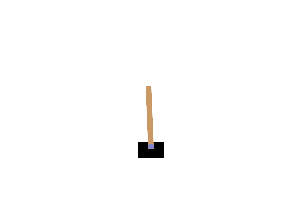

In [5]:
after_shots, after_steps = record_episode(model, seed=0, every=5)
print("学習後: 続いた回数", after_steps)

save_gif(before_shots, FIGURES / "ch01_before.gif", duration=100)
save_gif(after_shots, FIGURES / "ch01_after.gif", duration=100)
Image(filename=FIGURES / "ch01_after.gif")

**期待する結果**（VS Code などで実行した場合）: 続いた回数は 500 で、GIF では、台車が小刻みに左右へ動きながら、棒をほぼまっすぐに保ち続けます。

GitHub でこの Notebook を読んでいる場合、上の出力の GIF は表示されないことがあります（著者が GitHub の private リポジトリで確かめたときは表示されませんでした）。学習前と学習後の GIF は、この章のフォルダの [README.md](README.md) で見られます。次のセルでは、Notebook の中でも比べられるように、学習前と学習後のコマ送りの図を作ります。

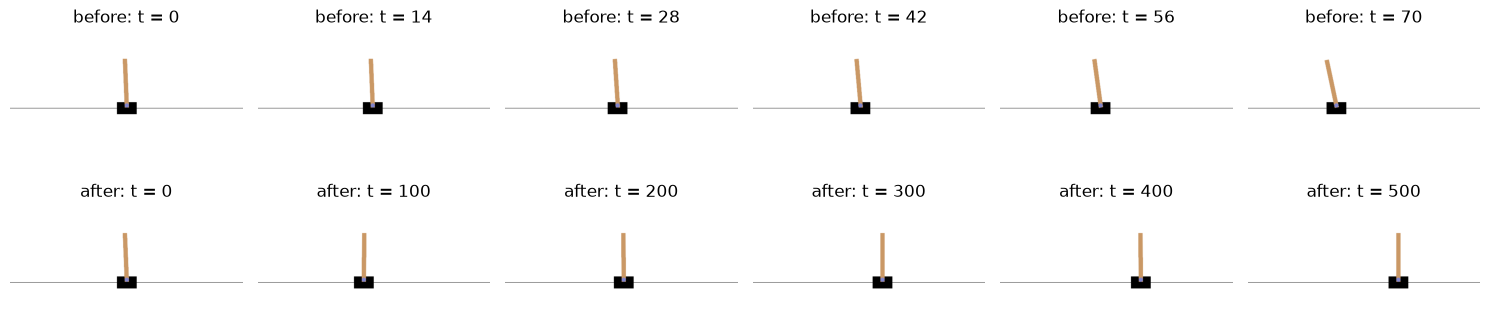

In [6]:
# 学習前（上の段）と学習後（下の段）の絵を、それぞれ等間隔に6枚選んで並べる
fig, axes = plt.subplots(2, 6, figsize=(15, 4.2))
for row, (label, shots) in enumerate([("before", before_shots), ("after", after_shots)]):
    picks = np.linspace(0, len(shots) - 1, 6).round().astype(int)
    for ax, i in zip(axes[row], picks):
        t, frame = shots[i]
        ax.imshow(frame[100:350, :])
        ax.set_title(f"{label}: t = {t}")
        ax.axis("off")
fig.tight_layout()
fig.savefig(FIGURES / "ch01_before_after_frames.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方。seed = 0 の場合）: 上の段（`before`）は学習前で、棒が少しずつ左へ傾いていき、`t = 70` で倒れたと判定される角度を超えて終わります。下の段（`after`）は学習後で、`t = 500` まで棒がほぼまっすぐのままです。台車は少しずつ右へ動いていますが、画面の中に収まっています。

`frame[100:350, :]` は、絵（高さ 400 × 幅 600）のうち縦 100〜349 の画素を、横はすべて切り出す書き方です。台車が左右に動いても切れないように、横は切り出していません。

## 6. 学習曲線を見る

### 6-1. エピソードごとの報酬

**学習曲線**は、学習が進むにつれて成績がどう変わったかを表すグラフです。3節で環境を包んだ `Monitor` が、学習中の各エピソードの報酬の合計を記録しています。それを取り出して描きます。

学習中のエピソードの数: 301


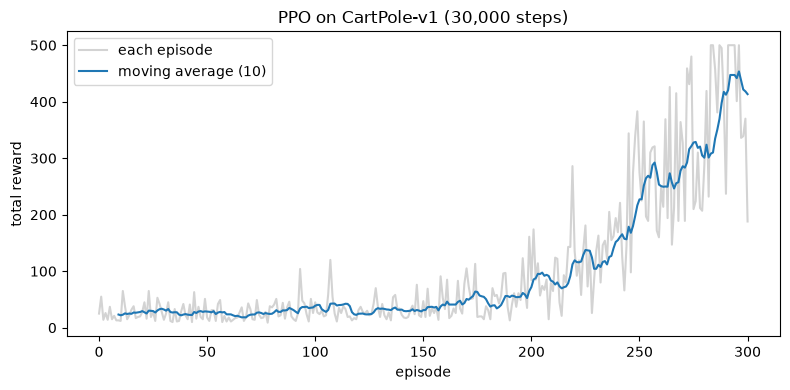

In [7]:
rewards = train_env.get_episode_rewards()
print("学習中のエピソードの数:", len(rewards))

window = 10
moving = np.convolve(rewards, np.ones(window) / window, mode="valid")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rewards, color="lightgray", label="each episode")
ax.plot(np.arange(window - 1, len(rewards)), moving, color="tab:blue", label=f"moving average ({window})")
ax.set_xlabel("episode")
ax.set_ylabel("total reward")
ax.set_title("PPO on CartPole-v1 (30,000 steps)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "ch01_learning_curve.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 横軸は学習中のエピソードの番号、縦軸はそのエピソードの報酬の合計（続いた回数）です。灰色の線が各エピソード、青い線が直前 10 エピソードの平均（移動平均）です。著者の環境では、学習中のエピソードは 301 回でした。始めのおよそ 150 エピソードは 20〜40 前後の短いエピソードが続き、200 エピソードを過ぎたあたりから報酬が大きく伸びて、終わり近くでは 500 に届くエピソードが出てきます。移動平均は、伸びる途中で何度か下がりながら上がっていきます。

始めのほうにエピソードが密集しているのは、短いエピソードほど同じステップ数の中に数多く入るためです。

コードの説明:

- `train_env.get_episode_rewards()` は、`Monitor` が記録した、エピソードごとの報酬の合計の一覧を返します
- `np.convolve(..., mode="valid")` は、隣り合う 10 個の平均を順にずらしながら計算する書き方で、移動平均を作っています。1 エピソードごとの値は上下に大きく揺れるので、傾向を見やすくするためです

### 6-2. TensorBoard で見る（任意）

4節の学習では、`tensorboard_log="logs"` の指定によって、学習の記録が、この Notebook と同じフォルダの `logs` フォルダに書き出されています。**TensorBoard** は、この記録をブラウザでグラフにして見る道具です。学習中にも、グラフが伸びていく様子を見られます。

教材のフォルダで開いた PowerShell で、次を実行します。

```powershell
.venv\Scripts\tensorboard --logdir chapters\ch01_first_training\logs
```

**期待する結果**（想定）: 表示の最後に、`http://localhost:6006/` のようなアドレスが表示されます。ブラウザでそのアドレスを開くと TensorBoard の画面が出て、`rollout/ep_rew_mean`（直近のエピソードの報酬の平均）などのグラフを見られます。見終わったら、PowerShell で `Ctrl`+`C` を押して止めます。

記録は `logs` フォルダの中の `ppo_cartpole_1` フォルダに書き出されます（著者が記録を読んで、`rollout/ep_rew_mean` の項目があることを確かめました）。4節をもう一度実行すると、`ppo_cartpole_2` のように番号の増えたフォルダが新しく作られます。`logs` フォルダは、学習のたびに作り直せる記録なので、Git の管理から外しています。

## 7. 遊んでみる：学習量を変える

学習量（`total_timesteps`）を変えると、結果はどう変わるでしょうか。5,000・10,000・20,000・30,000 ステップの4通りで、同じ seed のまま学習させ、成績と時間を比べます。著者の環境では、4通りで合わせて 1 分半ほどかかりました。

In [8]:
# 学習量を変えて学習させ、学習後の成績（10 回の平均）と時間を返す
def train_and_evaluate(total_timesteps, seed=0):
    env = Monitor(gym.make("CartPole-v1"))
    trial = PPO("MlpPolicy", env, seed=seed)
    start = time.perf_counter()
    trial.learn(total_timesteps=total_timesteps)
    elapsed = time.perf_counter() - start
    mean, std = evaluate_policy(trial, Monitor(gym.make("CartPole-v1")), n_eval_episodes=10, deterministic=True)
    return mean, std, elapsed


print("学習量     成績（平均 ± ばらつき）   時間")
for steps in [5_000, 10_000, 20_000, 30_000]:
    mean, std, elapsed = train_and_evaluate(steps)
    print(f"{steps:>6,}   {mean:6.1f} ± {std:5.1f}            {elapsed:4.0f} 秒")

学習量     成績（平均 ± ばらつき）   時間


 5,000    320.1 ± 145.3               7 秒


10,000    424.8 ±  94.2              12 秒


20,000    371.9 ±  74.2              24 秒


30,000    500.0 ±   0.0              37 秒


**期待する結果**（上の出力の読み方。著者の環境の場合）: 5,000 ステップでは、平均は 300 を超えますが、ばらつきが大きく、途中で倒れることがあります。30,000 ステップでは、10 回とも 500 に届きます。ただし、成績は学習量の順にきれいに並ぶとは限りません。著者の環境では、10,000 ステップのほうが 20,000 ステップより成績が良くなりました。

学習の途中では、方策が良くなったり、少し悪くなったりを繰り返しながら、全体として良くなっていきます。どの時点で学習を止めるかで、成績が上下します。6節の学習曲線でも、移動平均が一度下がってから再び上がる部分があるかどうか、見直してみてください。強化学習では、このように学習が揺れることはよくあります。後の章では、揺れを小さくする工夫や、良い時点のモデルを残す方法も扱います。

30,000 ステップの行は、4節と同じ条件（同じ seed・同じ学習量）なので、5節と同じ成績になります。

**やってみよう**: `for steps in [...]` の中の数を変えたり、`train_and_evaluate(steps, seed=1)` のように seed を変えたりして、もう一度実行してみてください。seed を変えると、同じ学習量でも成績が変わります。

## 8. まとめ

この章では、次のことを行いました。

| したこと | 使ったもの |
|---|---|
| 学習前のエージェントを見る | `PPO("MlpPolicy", ...)`、`model.predict()` |
| 学習させる | `model.learn(total_timesteps=...)` |
| 成績を測る | `evaluate_policy()` |
| 学習曲線を描く | `Monitor`、`get_episode_rewards()`、matplotlib |
| 学習量を変えて比べる | `train_and_evaluate()`（この章で作った関数） |

数行のコードと数十秒の学習で、すぐに倒れていた棒を、上限まで立て続けられるようになりました。ただし、PPO が中で何をしているのか、`predict` に渡した「状態」とは何だったのかは、まだ説明していません。次の第2章では、Gymnasium の環境の仕組み（状態・行動・報酬のやり取り）を、手で動かしながら確かめます。

- 次に読むもの: 第2章 Gymnasium の API の基本（準備中）

<!-- TODO（著者用）: 第2章ができたら ../ch02_gymnasium_api/ch02_gymnasium_api.ipynb へのリンクにする -->

## 出典

この章は、次の公式の文書と論文（2026-10-01 確認）をもとに、著者の言葉でまとめたものです。逐語の転載ではありません。

- Stable-Baselines3 Documentation, PPO: https://stable-baselines3.readthedocs.io/en/master/modules/ppo.html
- Stable-Baselines3 Documentation, Tensorboard Integration: https://stable-baselines3.readthedocs.io/en/master/guide/tensorboard.html
- J. Schulman et al., "Proximal Policy Optimization Algorithms", 2017: https://arxiv.org/abs/1707.06347
- Farama Foundation, Gymnasium Documentation（CartPole の環境の説明）: https://gymnasium.farama.org/environments/classic_control/cart_pole/

5節の GIF とコマ送りの図の絵は、Gymnasium（MIT License）の CartPole の描画処理が出力したものです。この教科書のライセンスと、使っている第三者のソフトウェアの一覧は、リポジトリの [LICENSE.md](../../LICENSE.md) にあります。